# Stage 1 Thesis Statistics Analysis

**Mục tiêu:** Phân tích 417 videos (70 categories) để chọn candidate window sizes cho Stage 2.

**Input:** `analysis/stage1/default/stage1_consolidated.parquet` (114 MB)

**Output:** 10 figures, 6 tables, candidate_window_sizes.json

## Section 0: Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import json
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set style
sns.set_palette("colorblind")
plt.rcParams['figure.figsize'] = (10, 6)
np.random.seed(42)

# Load parquet
df = pd.read_parquet("analysis/stage1/default/stage1_consolidated.parquet")

# Type coercion (CSV string → numeric)
num_cols = ["frame_idx", "num_frames_total",
            "maskmem_max_distance", "maskmem_min_distance", "maskmem_mean_distance",
            "n_maskmem_selected", "scan_depth", "n_candidates_rejected",
            "min_iou_of_selected", "mean_iou_of_selected",
            "prev_predicted_iou", "inference_time_ms",
            "membank_ram_bytes", "process_rss_bytes", "gpu_vram_bytes"]
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Drop frame 0 sentinel (max_distance = -1, no memory bank)
df_valid = df[df["maskmem_max_distance"] >= 0].copy()

# Explode Distribution A (per-selection distance)
df_A = df_valid[["category", "video_name", "frame_idx", "maskmem_distances"]].copy()
df_A["distance"] = df_A["maskmem_distances"].apply(lambda s: json.loads(s) if s else [])
df_A = df_A.explode("distance").dropna(subset=["distance"])
df_A["distance"] = df_A["distance"].astype(int)

print(f"✓ Loaded {len(df):,} rows")
print(f"✓ Videos: {df['video_name'].nunique()}")
print(f"✓ Categories: {df['category'].nunique()}")
print(f"✓ Valid frames (after drop frame 0): {len(df_valid):,}")
print(f"✓ Distribution A (selections): {len(df_A):,}")

✓ Loaded 1,063,842 rows
✓ Videos: 415
✓ Categories: 70
✓ Valid frames (after drop frame 0): 1,063,012
✓ Distribution A (selections): 6,369,659


In [2]:
def save_fig(fig, name: str) -> None:
    """Save figure as PNG (300 DPI) + PDF (vector)"""
    Path("figures/stage1").mkdir(parents=True, exist_ok=True)
    fig.savefig(f"figures/stage1/{name}.png", dpi=300, bbox_inches="tight")
    fig.savefig(f"figures/stage1/{name}.pdf", bbox_inches="tight")
    print(f"✓ Saved figures/stage1/{name}.{{png,pdf}}")

def save_table(df_table: pd.DataFrame, name: str, caption: str = "") -> None:
    """Save table as CSV + Markdown + LaTeX"""
    Path("tables/stage1").mkdir(parents=True, exist_ok=True)
    base = f"tables/stage1/{name}"
    df_table.to_csv(f"{base}.csv", index=False)
    with open(f"{base}.md", "w") as f:
        f.write(f"**{caption}**\n\n")
        f.write(df_table.to_markdown(index=False))
    with open(f"{base}.tex", "w") as f:
        f.write(f"% {caption}\n")
        f.write(df_table.to_latex(index=False, escape=False))
    print(f"✓ Saved tables/stage1/{name}.{{csv,md,tex}}")

print("✓ Helper functions defined")

✓ Helper functions defined


In [3]:
# Sanity checks
assert df["video_name"].nunique() >= 410, "Expected ≥410 videos"
assert df["category"].nunique() == 70, "Expected 70 categories"
assert df_valid["maskmem_max_distance"].min() >= 1, "Max distance should be ≥1"
assert df_A["distance"].min() >= 1, "Selection distance should be ≥1"
print(f"✓ All sanity checks passed ({df['video_name'].nunique()} videos, {df['category'].nunique()} categories)")

✓ All sanity checks passed (415 videos, 70 categories)


## Section 1: Dataset Overview & Coverage

In [4]:
# Compute overview statistics
overview = pd.DataFrame([
    ("Videos analyzed", f"{df['video_name'].nunique()} / 420"),
    ("Categories covered", f"{df['category'].nunique()} / 70"),
    ("Total frames (incl. frame 0)", f"{len(df):,}"),
    ("Valid frames (drop frame 0)", f"{len(df_valid):,}"),
    ("Total selections (Dist A)", f"{len(df_A):,}"),
    ("Mean frames/video", f"{df.groupby('video_name').size().mean():.0f}"),
    ("Median frames/video", f"{df.groupby('video_name').size().median():.0f}"),
    ("Min frames/video", f"{df.groupby('video_name').size().min()}"),
    ("Max frames/video", f"{df.groupby('video_name').size().max()}"),
], columns=["Metric", "Value"])

print(overview.to_markdown(index=False))

| Metric                       | Value     |
|:-----------------------------|:----------|
| Videos analyzed              | 415 / 420 |
| Categories covered           | 70 / 70   |
| Total frames (incl. frame 0) | 1,063,842 |
| Valid frames (drop frame 0)  | 1,063,012 |
| Total selections (Dist A)    | 6,369,659 |
| Mean frames/video            | 2563      |
| Median frames/video          | 2160      |
| Min frames/video             | 1000      |
| Max frames/video             | 9193      |


In [5]:
save_table(overview, "01_stage1_overview",
           caption="Table 1.1: Stage 1 Dataset Overview")

✓ Saved tables/stage1/01_stage1_overview.{csv,md,tex}


In [6]:
# Compute overview statistics
overview = pd.DataFrame([
    ("Videos analyzed", f"{df['video_name'].nunique()} / 420"),
    ("Categories covered", f"{df['category'].nunique()} / 70"),
    ("Total frames (incl. frame 0)", f"{len(df):,}"),
    ("Valid frames (drop frame 0)", f"{len(df_valid):,}"),
    ("Total selections (Dist A)", f"{len(df_A):,}"),
    ("Mean frames/video", f"{df.groupby('video_name').size().mean():.0f}"),
    ("Median frames/video", f"{df.groupby('video_name').size().median():.0f}"),
    ("Min frames/video", f"{df.groupby('video_name').size().min()}"),
    ("Max frames/video", f"{df.groupby('video_name').size().max()}"),
], columns=["Metric", "Value"])

print(overview.to_markdown(index=False))

| Metric                       | Value     |
|:-----------------------------|:----------|
| Videos analyzed              | 415 / 420 |
| Categories covered           | 70 / 70   |
| Total frames (incl. frame 0) | 1,063,842 |
| Valid frames (drop frame 0)  | 1,063,012 |
| Total selections (Dist A)    | 6,369,659 |
| Mean frames/video            | 2563      |
| Median frames/video          | 2160      |
| Min frames/video             | 1000      |
| Max frames/video             | 9193      |


In [7]:
save_table(overview, "01_stage1_overview",
           caption="Table 1.1: Stage 1 Dataset Overview")

✓ Saved tables/stage1/01_stage1_overview.{csv,md,tex}


## Section 2: Distribution A & B Analysis

In [8]:
# Distribution B: per-frame max distance (primary metric)
dist_B = df_valid["maskmem_max_distance"]
dist_B_stats = pd.DataFrame([
    ("N (frames)", f"{len(dist_B):,}"),
    ("Mean", f"{dist_B.mean():.1f}"),
    ("Std", f"{dist_B.std():.1f}"),
    ("Min", f"{dist_B.min()}"),
    *[(f"P{p}", f"{int(np.percentile(dist_B, p))}")
      for p in [25, 50, 75, 90, 95, 99, 100]],
], columns=["Statistic", "Value"])

print("Distribution B (per-frame max distance) — DRIVES WINDOW SIZE SELECTION:")
print(dist_B_stats.to_markdown(index=False))
save_table(dist_B_stats, "03_distribution_B_stats",
           caption="Table 2.2: Distribution B (per-frame max distance) statistics — drives window size selection")

Distribution B (per-frame max distance) — DRIVES WINDOW SIZE SELECTION:
| Statistic   |         Value |
|:------------|--------------:|
| N (frames)  |   1.06301e+06 |
| Mean        |   9           |
| Std         |  29.4         |
| Min         |   1           |
| P25         |   6           |
| P50         |   6           |
| P75         |   6           |
| P90         |   6           |
| P95         |   8           |
| P99         |  76           |
| P100        | 913           |
✓ Saved tables/stage1/03_distribution_B_stats.{csv,md,tex}


✓ Saved figures/stage1/02_dist_B_histogram.{png,pdf}


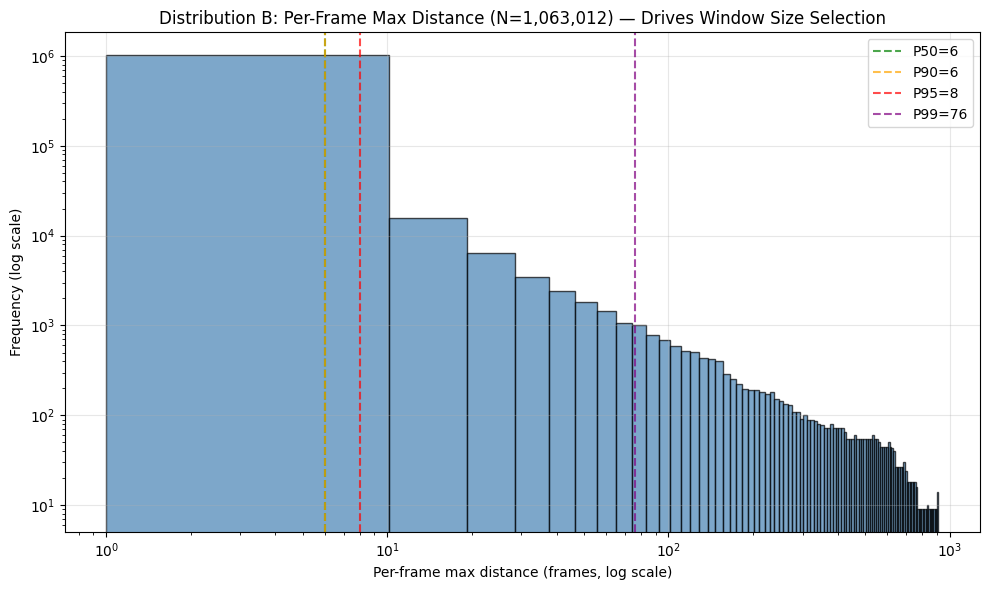

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(dist_B, bins=100, log=True, alpha=0.7, edgecolor='black', color='steelblue')
ax.set_xscale('log')
ax.set_xlabel('Per-frame max distance (frames, log scale)')
ax.set_ylabel('Frequency (log scale)')
ax.set_title(f'Distribution B: Per-Frame Max Distance (N={len(dist_B):,}) — Drives Window Size Selection')

percentile_values = {p: int(np.percentile(dist_B, p)) for p in [50, 90, 95, 99]}
colors = ['green', 'orange', 'red', 'purple']
for (p, val), color in zip(percentile_values.items(), colors):
    ax.axvline(val, color=color, linestyle='--', alpha=0.7,
               label=f'P{p}={val}')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
save_fig(fig, "02_dist_B_histogram")
plt.show()

✓ Saved figures/stage1/03_dist_B_cdf.{png,pdf}


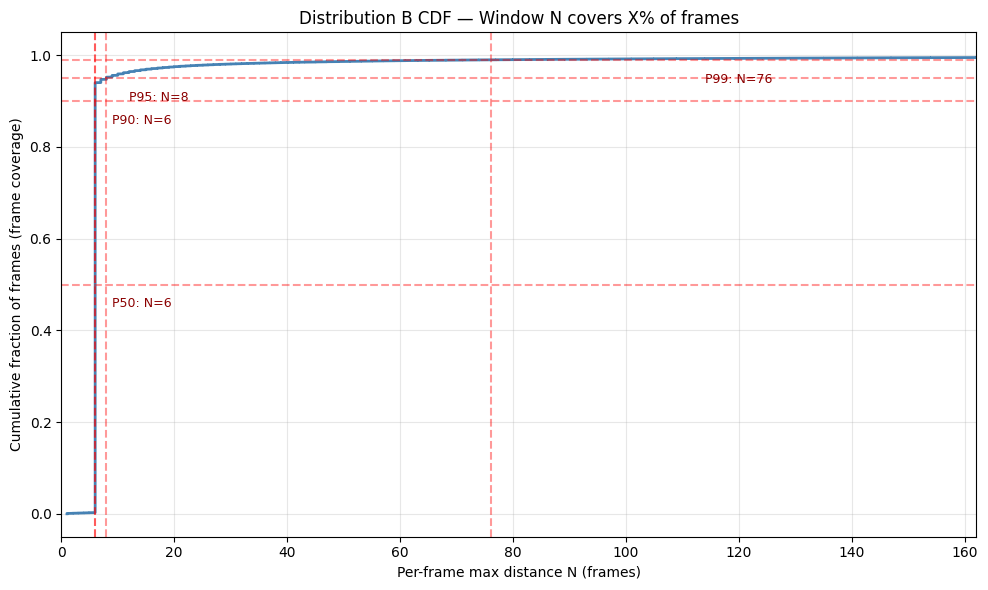

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))
sorted_B = np.sort(dist_B)
cdf = np.arange(1, len(sorted_B) + 1) / len(sorted_B)
ax.plot(sorted_B, cdf, linewidth=2, color='steelblue')
ax.set_xlabel('Per-frame max distance N (frames)')
ax.set_ylabel('Cumulative fraction of frames (frame coverage)')
ax.set_title('Distribution B CDF — Window N covers X% of frames')
ax.grid(True, alpha=0.3)

for p in [50, 90, 95, 99]:
    val = int(np.percentile(dist_B, p))
    ax.axvline(val, color='red', linestyle='--', alpha=0.4)
    ax.axhline(p/100, color='red', linestyle='--', alpha=0.4)
    ax.annotate(f'P{p}: N={val}', xy=(val, p/100),
                xytext=(val*1.5, p/100 - 0.05),
                fontsize=9, color='darkred')

ax.set_xlim(0, np.percentile(dist_B, 99.5))
plt.tight_layout()
save_fig(fig, "03_dist_B_cdf")
plt.show()

In [11]:
# Distribution A: per-selection temporal distance
percentiles = [25, 50, 75, 90, 95, 99, 100]
dist_A_stats = pd.DataFrame([
    ("N (total selections)", f"{len(df_A):,}"),
    ("Mean", f"{df_A['distance'].mean():.1f}"),
    ("Std", f"{df_A['distance'].std():.1f}"),
    ("Min", f"{df_A['distance'].min()}"),
    *[(f"P{p}", f"{int(np.percentile(df_A['distance'], p))}")
      for p in percentiles],
], columns=["Statistic", "Value"])

print("Distribution A (per-selection distance):")
print(dist_A_stats.to_markdown(index=False))
save_table(dist_A_stats, "02_distribution_A_stats",
           caption="Table 2.1: Distribution A (per-selection distance) statistics")

Distribution A (per-selection distance):
| Statistic            |         Value |
|:---------------------|--------------:|
| N (total selections) |   6.36966e+06 |
| Mean                 |   5.8         |
| Std                  |  26.6         |
| Min                  |   1           |
| P25                  |   2           |
| P50                  |   4           |
| P75                  |   5           |
| P90                  |   6           |
| P95                  |   6           |
| P99                  |  54           |
| P100                 | 913           |
✓ Saved tables/stage1/02_distribution_A_stats.{csv,md,tex}


✓ Saved figures/stage1/01_dist_A_histogram.{png,pdf}


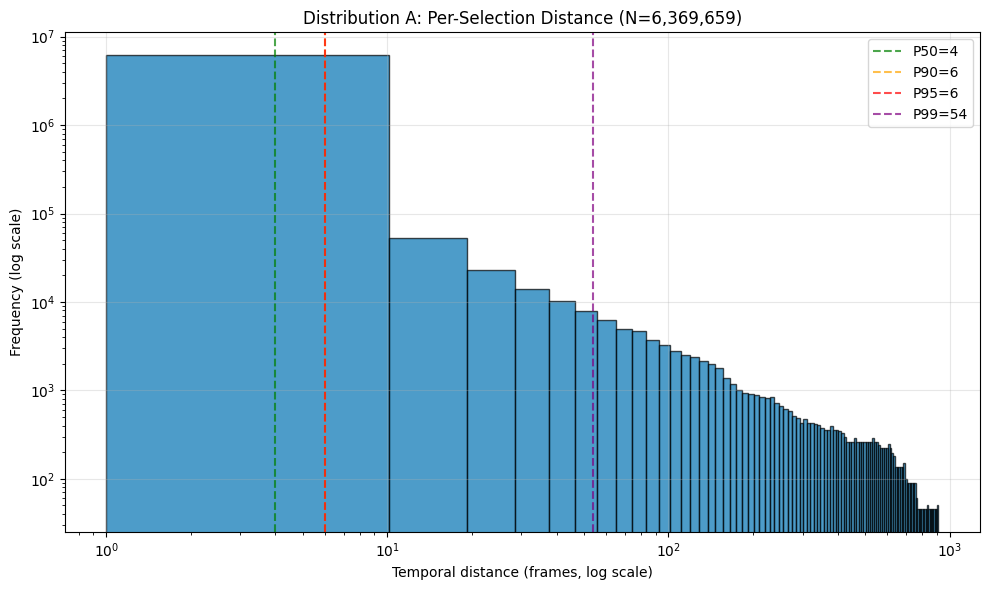

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(df_A["distance"], bins=100, log=True, alpha=0.7, edgecolor='black')
ax.set_xscale('log')
ax.set_xlabel('Temporal distance (frames, log scale)')
ax.set_ylabel('Frequency (log scale)')
ax.set_title(f'Distribution A: Per-Selection Distance (N={len(df_A):,})')

# Vertical lines at percentiles
percentile_values = {p: int(np.percentile(df_A['distance'], p))
                     for p in [50, 90, 95, 99]}
colors = ['green', 'orange', 'red', 'purple']
for (p, val), color in zip(percentile_values.items(), colors):
    ax.axvline(val, color=color, linestyle='--', alpha=0.7,
               label=f'P{p}={val}')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
save_fig(fig, "01_dist_A_histogram")
plt.show()

## Section 3: Coverage Curves

In [13]:
candidate_grid = [7, 10, 15, 25, 50, 100, 150, 200, 300, 500, 750, 1000, 1500, 2000, 3000]
selection_coverage = [(df_A["distance"] <= N).mean() for N in candidate_grid]
frame_coverage = [(df_valid["maskmem_max_distance"] <= N).mean() for N in candidate_grid]

coverage_df = pd.DataFrame({
    "N": candidate_grid,
    "selection_coverage": selection_coverage,
    "frame_coverage": frame_coverage,
})
print(coverage_df.to_markdown(index=False, floatfmt=".4f"))

|         N |   selection_coverage |   frame_coverage |
|----------:|---------------------:|-----------------:|
|    7.0000 |               0.9672 |           0.9473 |
|   10.0000 |               0.9734 |           0.9593 |
|   15.0000 |               0.9789 |           0.9696 |
|   25.0000 |               0.9842 |           0.9786 |
|   50.0000 |               0.9895 |           0.9865 |
|  100.0000 |               0.9937 |           0.9920 |
|  150.0000 |               0.9957 |           0.9946 |
|  200.0000 |               0.9967 |           0.9959 |
|  300.0000 |               0.9979 |           0.9974 |
|  500.0000 |               0.9991 |           0.9989 |
|  750.0000 |               0.9999 |           0.9998 |
| 1000.0000 |               1.0000 |           1.0000 |
| 1500.0000 |               1.0000 |           1.0000 |
| 2000.0000 |               1.0000 |           1.0000 |
| 3000.0000 |               1.0000 |           1.0000 |


✓ Saved figures/stage1/04_coverage_curves.{png,pdf}


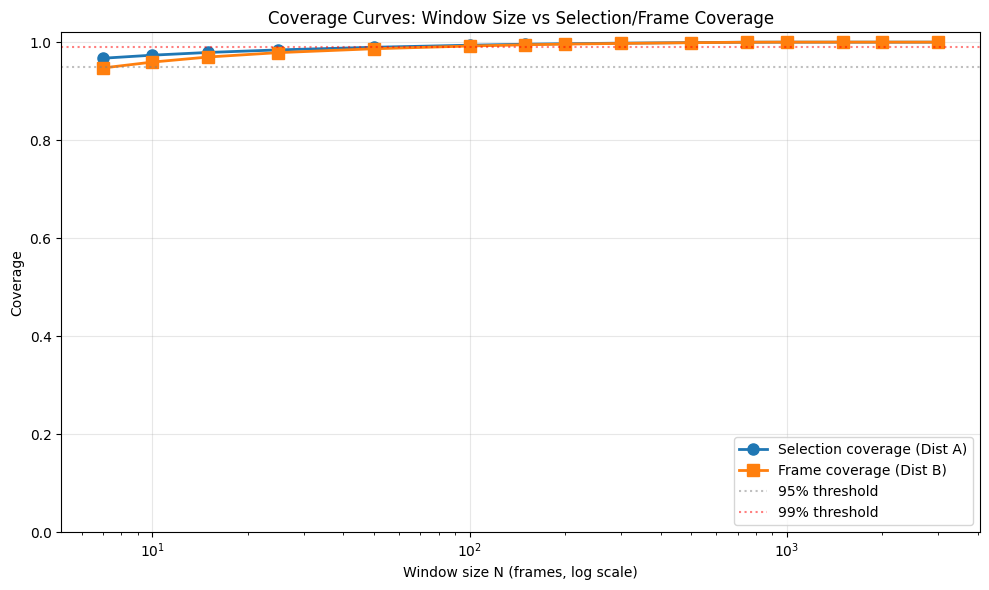


📊 Insight: Frame coverage tăng chậm hơn selection coverage vì max ≥ individual distances.
   N=200 → frame coverage = 99.6%
   N=500 → frame coverage = 99.9%
   N=1000 → frame coverage = 100.0%


In [14]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(candidate_grid, selection_coverage, 'o-', label='Selection coverage (Dist A)',
        linewidth=2, markersize=8, color='tab:blue')
ax.plot(candidate_grid, frame_coverage, 's-', label='Frame coverage (Dist B)',
        linewidth=2, markersize=8, color='tab:orange')
ax.set_xscale('log')
ax.set_xlabel('Window size N (frames, log scale)')
ax.set_ylabel('Coverage')
ax.set_title('Coverage Curves: Window Size vs Selection/Frame Coverage')
ax.set_ylim(0, 1.02)
ax.axhline(0.95, color='gray', linestyle=':', alpha=0.5, label='95% threshold')
ax.axhline(0.99, color='red', linestyle=':', alpha=0.5, label='99% threshold')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
save_fig(fig, "04_coverage_curves")
plt.show()

print(f"\n📊 Insight: Frame coverage tăng chậm hơn selection coverage vì max ≥ individual distances.")
print(f"   N=200 → frame coverage = {frame_coverage[candidate_grid.index(200)]:.1%}")
print(f"   N=500 → frame coverage = {frame_coverage[candidate_grid.index(500)]:.1%}")
print(f"   N=1000 → frame coverage = {frame_coverage[candidate_grid.index(1000)]:.1%}")

## Section 4: Per-Category Analysis

In [15]:
def percentile_func(p):
    def _f(x):
        return np.percentile(x, p)
    _f.__name__ = f"P{p}"
    return _f

per_cat = df_valid.groupby("category").agg(
    n_videos=("video_name", "nunique"),
    n_frames=("frame_idx", "count"),
    P50=("maskmem_max_distance", percentile_func(50)),
    P75=("maskmem_max_distance", percentile_func(75)),
    P90=("maskmem_max_distance", percentile_func(90)),
    P99=("maskmem_max_distance", percentile_func(99)),
    P100=("maskmem_max_distance", "max"),
    mean=("maskmem_max_distance", "mean"),
    std=("maskmem_max_distance", "std"),
).reset_index().sort_values("P50", ascending=False)

per_cat = per_cat.round({"P50": 0, "P75": 0, "P90": 0, "P99": 0, "mean": 1, "std": 1})
print(f"Per-category summary ({len(per_cat)} categories):\n")
print("Top 10 hardest (highest P50):")
print(per_cat.head(10).to_markdown(index=False))
print("\nBottom 10 easiest (lowest P50):")
print(per_cat.tail(10).to_markdown(index=False))

save_table(per_cat, "04_per_category_summary",
           caption=f"Table 4.1: Per-Category Summary ({len(per_cat)} categories sorted by P50)")

Per-category summary (70 categories):

Top 10 hardest (highest P50):
| category   |   n_videos |   n_frames |   P50 |   P75 |   P90 |   P99 |   P100 |   mean |   std |
|:-----------|-----------:|-----------:|------:|------:|------:|------:|-------:|-------:|------:|
| yoyo       |          6 |      20595 |     7 |    12 |    19 |    33 |     59 |   10.2 |   6.1 |
| airplane   |          6 |      18055 |     6 |     6 |     6 |    29 |    170 |    6.9 |   9.5 |
| bear       |          6 |      12602 |     6 |     6 |     6 |     6 |     19 |    6   |   0.4 |
| bicycle    |          6 |      12788 |     6 |     6 |     6 |    50 |    163 |    7.3 |  10.8 |
| bird       |          6 |      15130 |     6 |     6 |     6 |    21 |     58 |    6.4 |   3.1 |
| basketball |          6 |      15231 |     6 |     6 |    10 |    53 |    125 |    8.1 |   9.2 |
| boat       |          6 |      11920 |     6 |     6 |     6 |     6 |     19 |    6   |   0.4 |
| book       |          6 |      14320 |

/tmp/ipykernel_3847507/2986474666.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_for_box, vert=False, labels=cat_order, patch_artist=True,


✓ Saved figures/stage1/05_per_category_boxplot.{png,pdf}


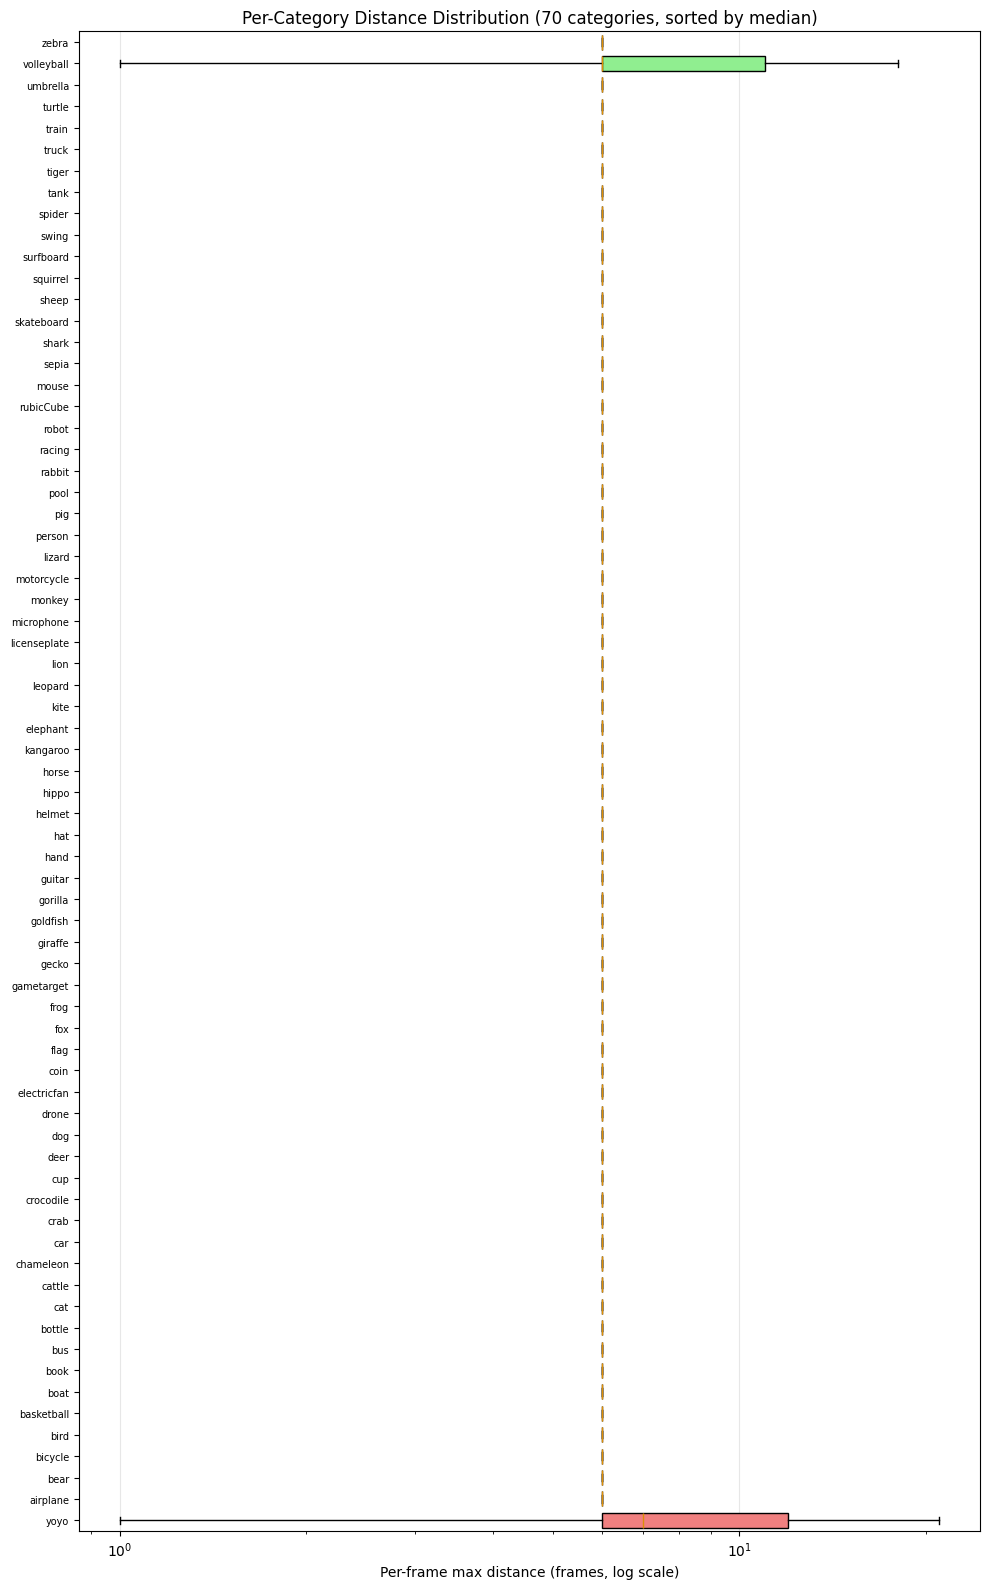


🔴 Top-5 hardest: ['yoyo', 'airplane', 'bear', 'bicycle', 'bird']
🟢 Bottom-5 easiest: ['train', 'turtle', 'umbrella', 'volleyball', 'zebra']


In [16]:
cat_order = per_cat.sort_values("P50", ascending=False)["category"].tolist()
top5 = cat_order[:5]
bottom5 = cat_order[-5:]

fig, ax = plt.subplots(figsize=(10, 16))
data_for_box = [df_valid.loc[df_valid["category"] == c, "maskmem_max_distance"].values
                for c in cat_order]

bp = ax.boxplot(data_for_box, vert=False, labels=cat_order, patch_artist=True,
                showfliers=False, widths=0.7)

for i, (patch, cat) in enumerate(zip(bp['boxes'], cat_order)):
    if cat in top5:
        patch.set_facecolor('lightcoral')
    elif cat in bottom5:
        patch.set_facecolor('lightgreen')
    else:
        patch.set_facecolor('lightgray')

ax.set_xscale('log')
ax.set_xlabel('Per-frame max distance (frames, log scale)')
ax.set_title(f'Per-Category Distance Distribution ({len(cat_order)} categories, sorted by median)')
ax.tick_params(axis='y', labelsize=7)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
save_fig(fig, "05_per_category_boxplot")
plt.show()

print(f"\n🔴 Top-5 hardest: {top5}")
print(f"🟢 Bottom-5 easiest: {bottom5}")

✓ Saved figures/stage1/06_outlier_categories.{png,pdf}


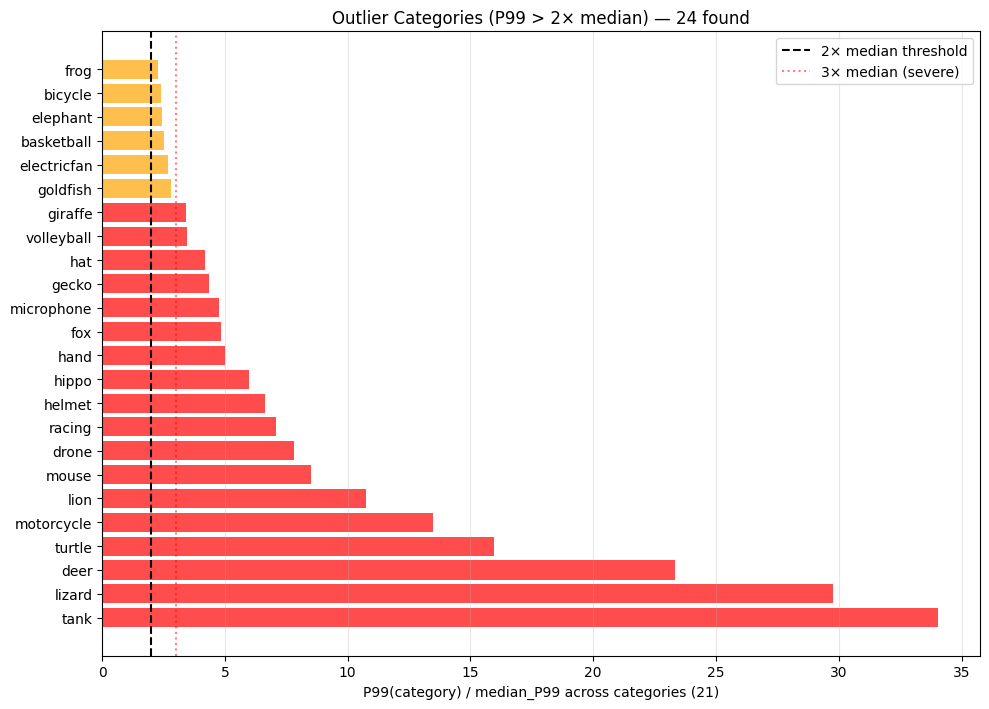


Outlier categories (24 found):
| category    |   P99 |   p99_ratio |
|:------------|------:|------------:|
| tank        |   715 |    34.0476  |
| lizard      |   625 |    29.7619  |
| deer        |   490 |    23.3333  |
| turtle      |   335 |    15.9524  |
| motorcycle  |   283 |    13.4762  |
| lion        |   226 |    10.7619  |
| mouse       |   179 |     8.52381 |
| drone       |   164 |     7.80952 |
| racing      |   149 |     7.09524 |
| helmet      |   139 |     6.61905 |
| hippo       |   126 |     6       |
| hand        |   105 |     5       |
| fox         |   102 |     4.85714 |
| microphone  |   100 |     4.7619  |
| gecko       |    91 |     4.33333 |
| hat         |    88 |     4.19048 |
| volleyball  |    73 |     3.47619 |
| giraffe     |    72 |     3.42857 |
| goldfish    |    59 |     2.80952 |
| electricfan |    56 |     2.66667 |
| basketball  |    53 |     2.52381 |
| elephant    |    51 |     2.42857 |
| bicycle     |    50 |     2.38095 |
| frog        |   

In [17]:
median_p99 = per_cat["P99"].median()
per_cat["p99_ratio"] = per_cat["P99"] / median_p99
outliers = per_cat[per_cat["p99_ratio"] > 2.0].sort_values("p99_ratio", ascending=False)

fig, ax = plt.subplots(figsize=(10, max(4, 0.3 * len(outliers))))
if len(outliers) > 0:
    colors = ['red' if r > 3 else 'orange' for r in outliers["p99_ratio"]]
    ax.barh(outliers["category"], outliers["p99_ratio"], color=colors, alpha=0.7)
    ax.axvline(2.0, color='black', linestyle='--', label='2× median threshold')
    ax.axvline(3.0, color='red', linestyle=':', alpha=0.5, label='3× median (severe)')
    ax.set_xlabel(f'P99(category) / median_P99 across categories ({median_p99:.0f})')
    ax.set_title(f'Outlier Categories (P99 > 2× median) — {len(outliers)} found')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='x')
else:
    ax.text(0.5, 0.5, 'No outlier categories (all P99 within 2× median)',
            ha='center', va='center', transform=ax.transAxes, fontsize=14)
    ax.set_title('Outlier Categories — None Found')

plt.tight_layout()
save_fig(fig, "06_outlier_categories")
plt.show()

print(f"\nOutlier categories ({len(outliers)} found):")
if len(outliers) > 0:
    print(outliers[["category", "P99", "p99_ratio"]].to_markdown(index=False))

## Section 5: Per-Attribute Analysis

In [18]:
attrs_to_analyze = ["full_occlusion", "out_of_view"]

for attr in attrs_to_analyze:
    df_valid[f"has_{attr}"] = df_valid["attributes"].apply(
        lambda s: attr in json.loads(s) if s else False
    )

results = []
for attr in attrs_to_analyze:
    active = df_valid.loc[df_valid[f"has_{attr}"], "maskmem_max_distance"]
    inactive = df_valid.loc[~df_valid[f"has_{attr}"], "maskmem_max_distance"]

    if len(active) == 0 or len(inactive) == 0:
        results.append((attr, len(active), np.nan, np.nan, np.nan, np.nan, np.nan, "Skipped (empty group)"))
        continue

    u_stat, p_value = stats.mannwhitneyu(active, inactive, alternative="two-sided")
    log_active = np.log1p(active)
    log_inactive = np.log1p(inactive)
    pooled_var = (log_active.var() + log_inactive.var()) / 2
    cohens_d = ((log_active.mean() - log_inactive.mean()) / np.sqrt(pooled_var)
                if pooled_var > 0 else 0.0)

    abs_d = abs(cohens_d)
    if abs_d < 0.2:
        effect = "Negligible"
    elif abs_d < 0.5:
        effect = "Small"
    elif abs_d < 0.8:
        effect = "Medium"
    else:
        effect = "Large"

    results.append((
        attr,
        len(active),
        round(active.mean(), 1),
        round(inactive.mean(), 1),
        round(active.median() - inactive.median(), 1),
        f"{p_value:.3e}",
        round(cohens_d, 3),
        effect,
    ))

attr_df = pd.DataFrame(results, columns=[
    "attribute", "n_active", "mean_active", "mean_inactive",
    "median_diff", "p_value", "cohens_d", "effect"
])
print("Per-attribute effect on max_distance:\n")
print(attr_df.to_markdown(index=False))

save_table(attr_df, "05_per_attribute_effect",
           caption="Table 5.1: Per-attribute effect on maskmem max distance (Mann-Whitney U + Cohen's d on log distance)")

Per-attribute effect on max_distance:

| attribute      |   n_active |   mean_active |   mean_inactive |   median_diff |   p_value |   cohens_d | effect   |
|:---------------|-----------:|--------------:|----------------:|--------------:|----------:|-----------:|:---------|
| full_occlusion |      15446 |          49.6 |             8.4 |             3 |         0 |      0.985 | Large    |
| out_of_view    |      13303 |          40.8 |             8.6 |            12 |         0 |      1.392 | Large    |
✓ Saved tables/stage1/05_per_attribute_effect.{csv,md,tex}


✓ Saved figures/stage1/07_attribute_stratified.{png,pdf}


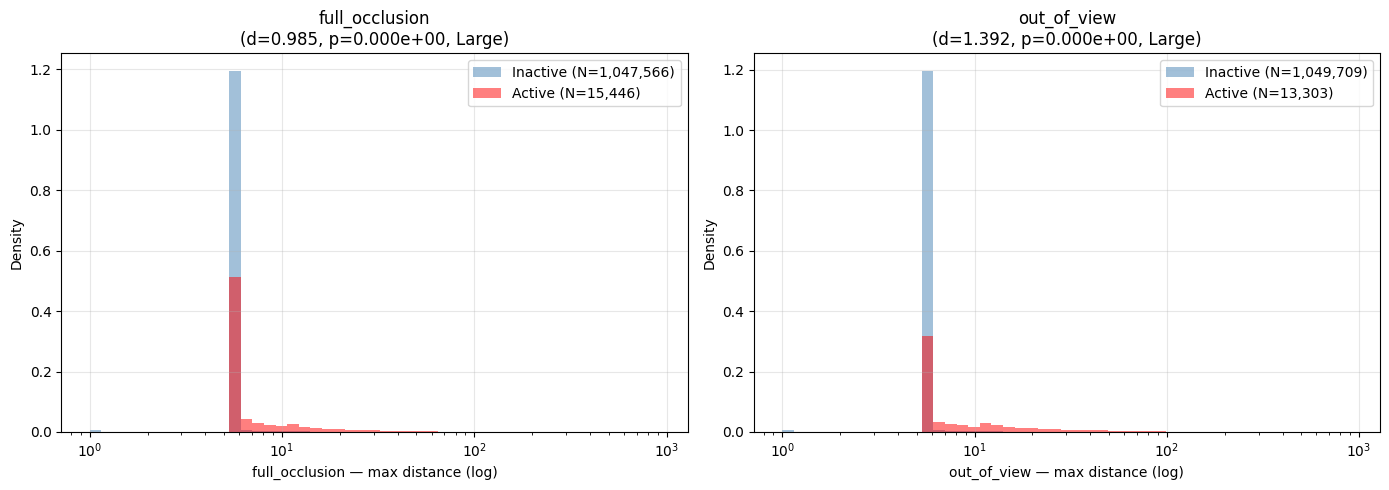

In [19]:
fig, axes = plt.subplots(1, len(attrs_to_analyze), figsize=(14, 5))
if len(attrs_to_analyze) == 1:
    axes = [axes]

for ax, attr in zip(axes, attrs_to_analyze):
    active = df_valid.loc[df_valid[f"has_{attr}"], "maskmem_max_distance"]
    inactive = df_valid.loc[~df_valid[f"has_{attr}"], "maskmem_max_distance"]

    bins = np.logspace(0, np.log10(df_valid["maskmem_max_distance"].max() + 1), 50)
    ax.hist(inactive, bins=bins, alpha=0.5, label=f"Inactive (N={len(inactive):,})",
            color='steelblue', density=True)
    ax.hist(active, bins=bins, alpha=0.5, label=f"Active (N={len(active):,})",
            color='red', density=True)
    ax.set_xscale('log')
    ax.set_xlabel(f'{attr} — max distance (log)')
    ax.set_ylabel('Density')

    row = attr_df[attr_df["attribute"] == attr].iloc[0]
    ax.set_title(f"{attr}\n(d={row['cohens_d']}, p={row['p_value']}, {row['effect']})")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
save_fig(fig, "07_attribute_stratified")
plt.show()

✓ Saved figures/stage1/08_attribute_effect_size.{png,pdf}


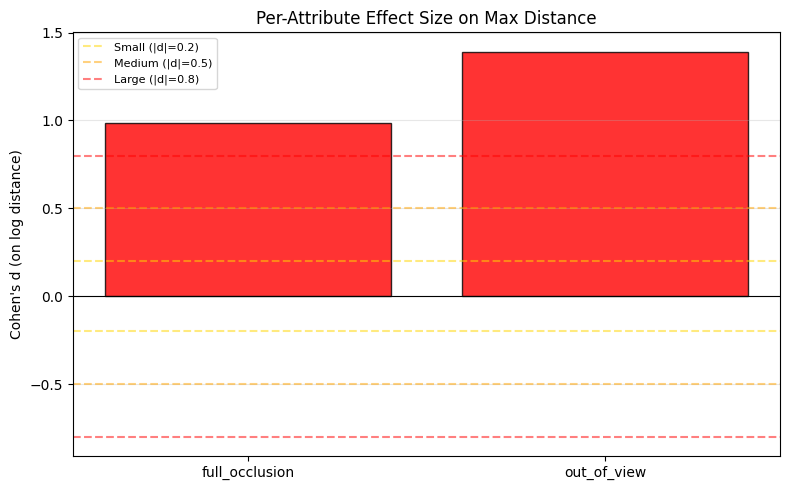

In [20]:
fig, ax = plt.subplots(figsize=(8, 5))
attr_names = attr_df["attribute"].tolist()
d_values = attr_df["cohens_d"].astype(float).tolist()
colors = ['lightgray' if abs(d) < 0.2
          else 'gold' if abs(d) < 0.5
          else 'orange' if abs(d) < 0.8
          else 'red' for d in d_values]

ax.bar(attr_names, d_values, color=colors, edgecolor='black', alpha=0.8)
ax.axhline(0.2, color='gold', linestyle='--', alpha=0.5, label='Small (|d|=0.2)')
ax.axhline(0.5, color='orange', linestyle='--', alpha=0.5, label='Medium (|d|=0.5)')
ax.axhline(0.8, color='red', linestyle='--', alpha=0.5, label='Large (|d|=0.8)')
ax.axhline(-0.2, color='gold', linestyle='--', alpha=0.5)
ax.axhline(-0.5, color='orange', linestyle='--', alpha=0.5)
ax.axhline(-0.8, color='red', linestyle='--', alpha=0.5)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel("Cohen's d (on log distance)")
ax.set_title("Per-Attribute Effect Size on Max Distance")
ax.legend(loc='best', fontsize=8)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
save_fig(fig, "08_attribute_effect_size")
plt.show()

## Section 6: Memory Bank RAM Preliminary

In [21]:
video_lengths = df_valid.groupby("video_name")["frame_idx"].max().sort_values()

short_videos = video_lengths[video_lengths.between(400, 700)].index.tolist()
medium_videos = video_lengths[video_lengths.between(1300, 1700)].index.tolist()
long_videos = video_lengths[video_lengths > 2300].index.tolist()

np.random.seed(42)
sample_videos = []
if short_videos:
    sample_videos.append(np.random.choice(short_videos))
if medium_videos:
    sample_videos.extend(np.random.choice(medium_videos, size=min(2, len(medium_videos)), replace=False))
if long_videos:
    sample_videos.extend(np.random.choice(long_videos, size=min(2, len(long_videos)), replace=False))

print(f"Sampled {len(sample_videos)} videos for RAM growth analysis:")
for v in sample_videos:
    print(f"  {v}: {video_lengths[v]} frames")

Sampled 4 videos for RAM growth analysis:
  hippo-11: 1325 frames
  train-3: 1617 frames
  hat-19: 2540 frames
  licenseplate-3: 3670 frames


In [22]:
growth_rows = []
for vid in sample_videos:
    df_vid = df_valid[df_valid["video_name"] == vid].sort_values("frame_idx")
    df_vid_clean = df_vid.dropna(subset=["membank_ram_bytes"])

    if len(df_vid_clean) < 10:
        print(f"⚠ Skipping {vid} — insufficient RAM data ({len(df_vid_clean)} rows)")
        continue

    ram_mb = df_vid_clean["membank_ram_bytes"] / 1e6
    slope, intercept, r_value, _, _ = stats.linregress(df_vid_clean["frame_idx"], ram_mb)

    growth_rows.append({
        "video_id": vid,
        "length": int(video_lengths[vid]),
        "slope_MB_per_frame": round(slope, 4),
        "R_squared": round(r_value**2, 4),
        "peak_RAM_MB": round(ram_mb.max(), 1),
        "final_RAM_MB": round(ram_mb.iloc[-1], 1),
    })

    if r_value**2 < 0.95:
        print(f"⚠ {vid}: R²={r_value**2:.3f} < 0.95 — not strictly linear")

growth_df = pd.DataFrame(growth_rows)
print("\nGrowth rate summary:")
print(growth_df.to_markdown(index=False))

save_table(growth_df, "06_ram_growth_rates",
           caption="Table 6.1: Memory bank RAM growth rates (5 sample videos)")


Growth rate summary:
| video_id       |   length |   slope_MB_per_frame |   R_squared |   peak_RAM_MB |   final_RAM_MB |
|:---------------|---------:|---------------------:|------------:|--------------:|---------------:|
| hippo-11       |     1325 |               0.5243 |           1 |         694.7 |          694.7 |
| train-3        |     1617 |               0.5243 |           1 |         847.8 |          847.8 |
| hat-19         |     2540 |               0.5243 |           1 |        1331.7 |         1331.7 |
| licenseplate-3 |     3670 |               0.5243 |           1 |        1924.1 |         1924.1 |
✓ Saved tables/stage1/06_ram_growth_rates.{csv,md,tex}


✓ Saved figures/stage1/09_membank_ram_growth.{png,pdf}


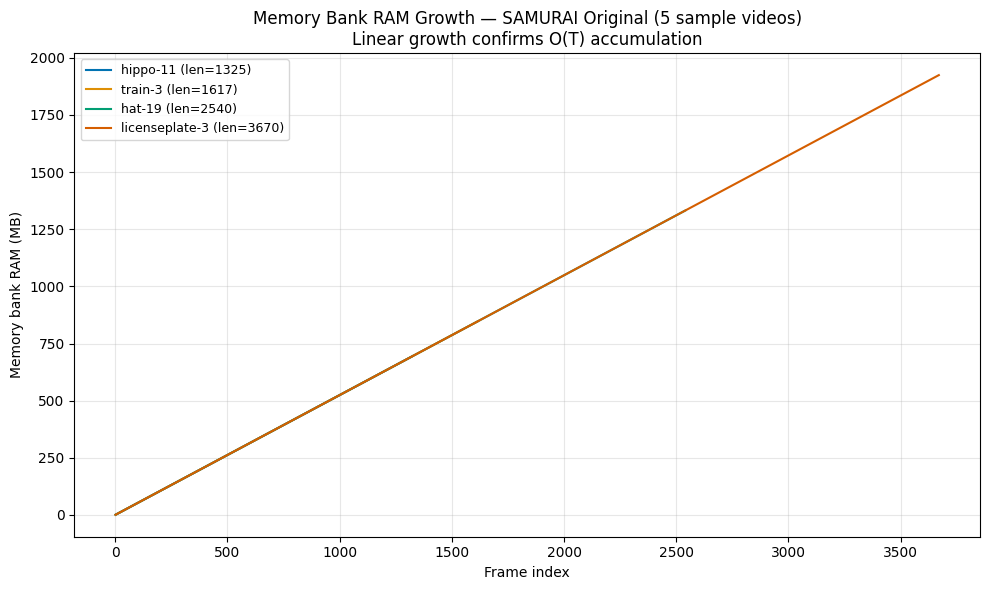


📊 Average slope: 0.524 MB/frame
   Stage 2 SlidingWindow expected to bound at N × 0.524 MB.
   Example: N=500 → ~262 MB bounded (vs SAMURAI gốc grows unbounded).


In [23]:
fig, ax = plt.subplots(figsize=(10, 6))
colors = sns.color_palette("colorblind", len(sample_videos))

for vid, color in zip(sample_videos, colors):
    df_vid = df_valid[df_valid["video_name"] == vid].sort_values("frame_idx")
    df_vid = df_vid.dropna(subset=["membank_ram_bytes"])
    if len(df_vid) < 10:
        continue
    ax.plot(df_vid["frame_idx"], df_vid["membank_ram_bytes"] / 1e6,
            label=f"{vid} (len={int(video_lengths[vid])})",
            linewidth=1.5, color=color)

ax.set_xlabel('Frame index')
ax.set_ylabel('Memory bank RAM (MB)')
ax.set_title('Memory Bank RAM Growth — SAMURAI Original (5 sample videos)\nLinear growth confirms O(T) accumulation')
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
save_fig(fig, "09_membank_ram_growth")
plt.show()

if len(growth_df) > 0:
    avg_slope = growth_df["slope_MB_per_frame"].mean()
    print(f"\n📊 Average slope: {avg_slope:.3f} MB/frame")
    print(f"   Stage 2 SlidingWindow expected to bound at N × {avg_slope:.3f} MB.")
    print(f"   Example: N=500 → ~{500 * avg_slope:.0f} MB bounded (vs SAMURAI gốc grows unbounded).")

## Section 7: Candidate Window Sizes Selection

In [24]:
def round_to_nice(val):
    if val < 10:
        return int(val)
    elif val < 50:
        return int(np.ceil(val / 5) * 5)
    elif val < 200:
        return int(np.ceil(val / 25) * 25)
    elif val < 1000:
        return int(np.ceil(val / 50) * 50)
    else:
        return int(np.ceil(val / 100) * 100)

dist_B = df_valid["maskmem_max_distance"]
sources = [
    ("K (lower bound)", 7, 7),
    ("P50(B)", np.percentile(dist_B, 50), round_to_nice(np.percentile(dist_B, 50))),
    ("P75(B)", np.percentile(dist_B, 75), round_to_nice(np.percentile(dist_B, 75))),
    ("P90(B)", np.percentile(dist_B, 90), round_to_nice(np.percentile(dist_B, 90))),
    ("P95(B)", np.percentile(dist_B, 95), round_to_nice(np.percentile(dist_B, 95))),
    ("P99(B)", np.percentile(dist_B, 99), round_to_nice(np.percentile(dist_B, 99))),
    ("2×P99(B)", 2 * np.percentile(dist_B, 99), round_to_nice(2 * np.percentile(dist_B, 99))),
]

candidates_raw = []
for source, raw, rounded in sources:
    frame_cov = (dist_B <= rounded).mean()
    sel_cov = (df_A["distance"] <= rounded).mean()
    candidates_raw.append({
        "source": source,
        "raw_value": round(raw, 1),
        "rounded": rounded,
        "frame_coverage": round(frame_cov, 4),
        "selection_coverage": round(sel_cov, 4),
    })

candidates_df = pd.DataFrame(candidates_raw)
candidates_unique = sorted(set(candidates_df["rounded"].tolist()))

print("Candidate selection rationale:")
print(candidates_df.to_markdown(index=False))
print(f"\nFinal unique candidates (after dedup): {candidates_unique}")
print(f"Count: {len(candidates_unique)} values")

Candidate selection rationale:
| source          |   raw_value |   rounded |   frame_coverage |   selection_coverage |
|:----------------|------------:|----------:|-----------------:|---------------------:|
| K (lower bound) |           7 |         7 |           0.9473 |               0.9672 |
| P50(B)          |           6 |         6 |           0.9402 |               0.9639 |
| P75(B)          |           6 |         6 |           0.9402 |               0.9639 |
| P90(B)          |           6 |         6 |           0.9402 |               0.9639 |
| P95(B)          |           8 |         8 |           0.9522 |               0.9696 |
| P99(B)          |          76 |       100 |           0.992  |               0.9937 |
| 2×P99(B)        |         152 |       175 |           0.9954 |               0.9963 |

Final unique candidates (after dedup): [6, 7, 8, 100, 175]
Count: 5 values


✓ Saved figures/stage1/10_candidate_overlay_cdf.{png,pdf}


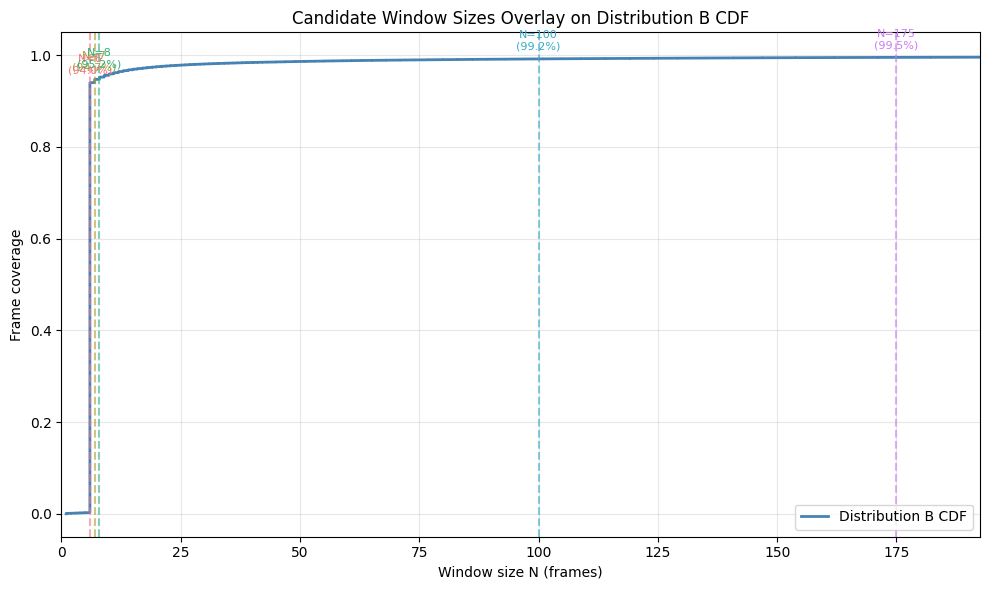

In [25]:
fig, ax = plt.subplots(figsize=(10, 6))
sorted_B = np.sort(dist_B)
cdf = np.arange(1, len(sorted_B) + 1) / len(sorted_B)
ax.plot(sorted_B, cdf, linewidth=2, color='steelblue', label='Distribution B CDF')
ax.set_xlabel('Window size N (frames)')
ax.set_ylabel('Frame coverage')
ax.set_title('Candidate Window Sizes Overlay on Distribution B CDF')
ax.grid(True, alpha=0.3)

colors_cand = sns.color_palette("husl", len(candidates_unique))
for N, color in zip(candidates_unique, colors_cand):
    cov = (dist_B <= N).mean()
    ax.axvline(N, color=color, linestyle='--', alpha=0.6, linewidth=1.5)
    ax.text(N, cov + 0.02, f'N={N}\n({cov:.1%})',
            fontsize=8, ha='center', color=color)

ax.set_xlim(0, max(candidates_unique) * 1.1)
ax.legend()
plt.tight_layout()
save_fig(fig, "10_candidate_overlay_cdf")
plt.show()

In [26]:
coverage_dict = {str(N): {"frame": round((dist_B <= N).mean(), 4),
                              "selection": round((df_A["distance"] <= N).mean(), 4)}
                     for N in candidates_unique}

output_json = {
    "candidate_window_sizes": candidates_unique,
    "rationale": "Percentile-based from Distribution B (per-frame max distance)",
    "coverage_at_candidates": coverage_dict,
    "generated_from": {
        "n_videos": int(df["video_name"].nunique()),
        "n_categories": int(df["category"].nunique()),
        "n_frames": int(len(df_valid)),
        "n_selections": int(len(df_A)),
    },
    "date": "2026-05-08",
    "spec_reference": "docs/superpowers/specs/2026-05-07-stage1-thesis-statistics-design.md",
}

Path("analysis/stage1").mkdir(parents=True, exist_ok=True)
with open("analysis/stage1/candidate_window_sizes.json", "w") as f:
    json.dump(output_json, f, indent=2)

print("✓ Saved analysis/stage1/candidate_window_sizes.json")
print(f"\nFinal candidates for Stage 2: {candidates_unique}")

✓ Saved analysis/stage1/candidate_window_sizes.json

Final candidates for Stage 2: [6, 7, 8, 100, 175]


## Section 8: Summary Tables for Thesis